## Import Libraries And Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('heart_disease_uci.csv')
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


## Inspect Missing Values and Duplicates

In [3]:
print("Dataset Shape:", df.shape)
print("Total Duplicates:", df.duplicated().sum())

missing_data = df.isnull().sum()
print("\nMissing Values per Column:")
print(missing_data[missing_data > 0])

Dataset Shape: (920, 16)
Total Duplicates: 0

Missing Values per Column:
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


## Impute Missing Numeric Data And Categorical Data

In [25]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Replace missing numeric values with the median of each column
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# Replace missing categorical values with the mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        # Added .infer_objects(copy=False) here to resolve the warning
        df[col] = df[col].fillna(df[col].mode()[0]).infer_objects(copy=False)
        
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,heart_disease_present,disease_label
0,1,63,male,cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0,Healthy
1,2,67,male,cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1,Heart Disease
2,3,67,male,cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1,Heart Disease
3,4,37,male,cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0,Healthy
4,5,41,female,cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,female,va long beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,flat,0.0,normal,1,1,Heart Disease
916,917,62,male,va long beach,typical angina,130.0,139.0,False,st-t abnormality,140.0,False,0.5,flat,0.0,normal,0,0,Healthy
917,918,55,male,va long beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,flat,0.0,fixed defect,2,1,Heart Disease
918,919,58,male,va long beach,asymptomatic,130.0,385.0,True,lv hypertrophy,140.0,False,0.5,flat,0.0,normal,0,0,Healthy


## Format and Standardize Data

In [5]:
for col in categorical_cols:
    if df[col].dtype == 'object':
        # Convert to lowercase and remove leading/trailing spaces
        df[col] = df[col].str.lower().str.strip()

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,male,cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,male,cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,male,cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,male,cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,female,cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


##  

In [20]:
# Create binary target variables if you haven't already
df['heart_disease_present'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df['disease_label'] = df['heart_disease_present'].map({0: 'Healthy', 1: 'Heart Disease'})

# Set a clean visual theme
sns.set_theme(style="whitegrid")

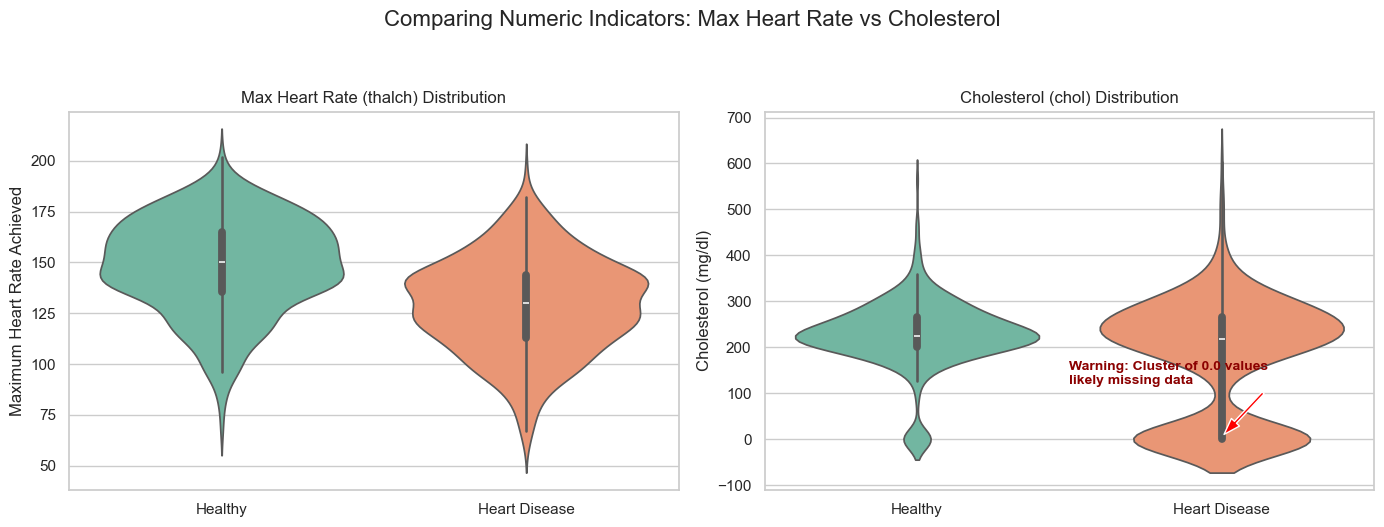

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Max Heart Rate Distribution
sns.violinplot(data=df, x='disease_label', y='thalch', hue='disease_label', ax=axes[0], palette='Set2')
axes[0].set_title('Max Heart Rate (thalch) Distribution', fontsize=12)
axes[0].set_ylabel('Maximum Heart Rate Achieved')
axes[0].set_xlabel('')

# Plot 2: Cholesterol Distribution
sns.violinplot(data=df, x='disease_label', y='chol', hue='disease_label', ax=axes[1], palette='Set2')
axes[1].set_title('Cholesterol (chol) Distribution', fontsize=12)
axes[1].set_ylabel('Cholesterol (mg/dl)')
axes[1].set_xlabel('')

# Add a warning note about the zero values in cholesterol
axes[1].annotate('Warning: Cluster of 0.0 values\nlikely missing data', 
                 xy=(1, 5), xytext=(0.5, 120),
                 arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
                 fontsize=10, color='darkred', weight='bold')

plt.suptitle('Comparing Numeric Indicators: Max Heart Rate vs Cholesterol', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

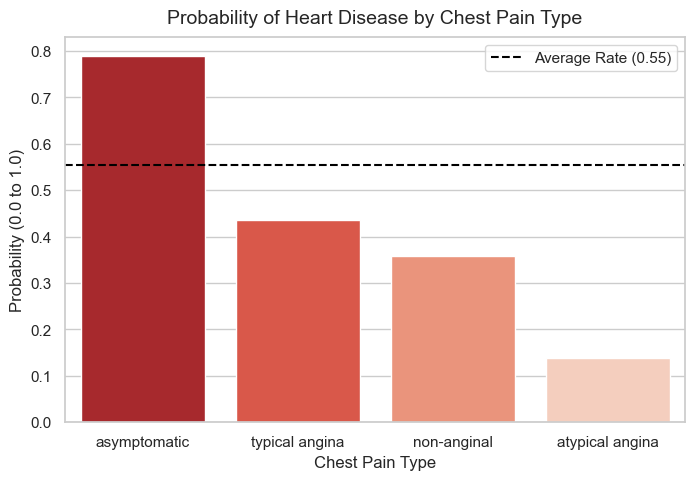

In [23]:
plt.figure(figsize=(8, 5))

# Calculate the probability of heart disease for each chest pain type
cp_props = df.groupby('cp')['heart_disease_present'].mean().reset_index()
cp_props = cp_props.sort_values('heart_disease_present', ascending=False)

# Create the proporti on bar chart
sns.barplot(data=cp_props, x='cp', y='heart_disease_present', palette='Reds_r', hue='cp', legend=False)
plt.title('Probability of Heart Disease by Chest Pain Type', fontsize=14, pad=10)
plt.ylabel('Probability (0.0 to 1.0)')
plt.xlabel('Chest Pain Type')

# Add a line showing the average disease rate across the whole dataset
avg_disease_rate = df['heart_disease_present'].mean()
plt.axhline(avg_disease_rate, color='black', linestyle='--', label=f'Average Rate ({avg_disease_rate:.2f})')
plt.legend()
plt.show()

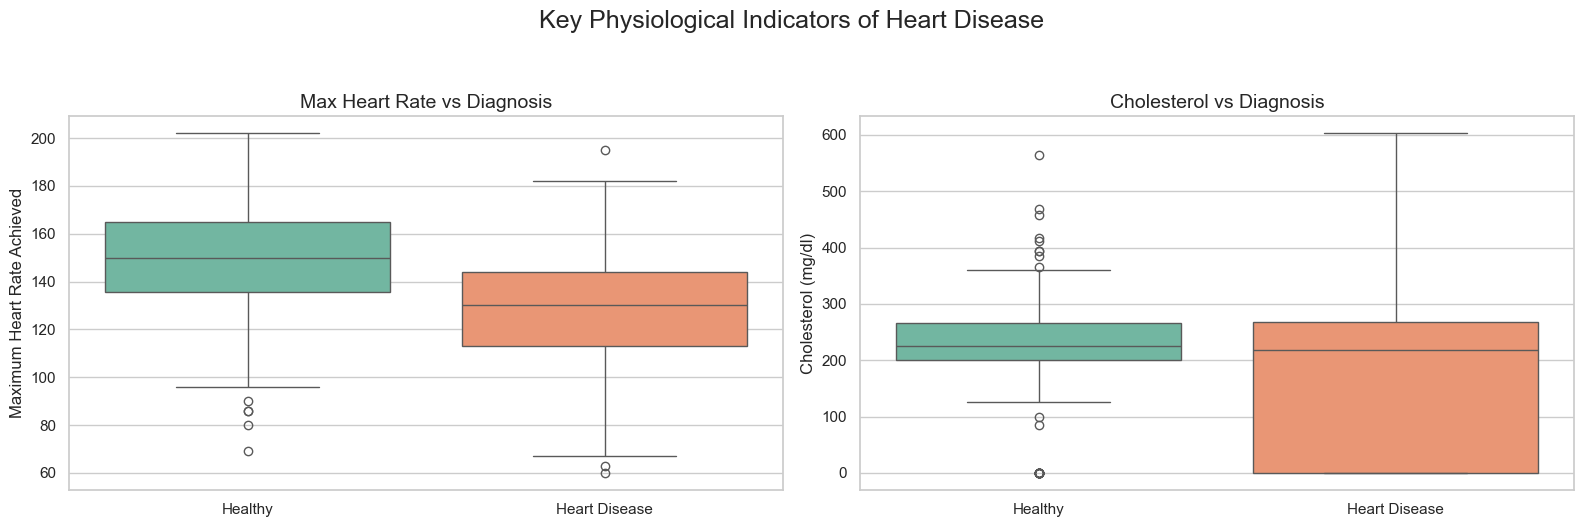

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Max Heart Rate vs Heart Disease (Boxplot)
sns.boxplot(data=df, x='disease_label', y='thalch', hue='disease_label', ax=axes[0], palette='Set2')
axes[0].set_title('Max Heart Rate vs Diagnosis', fontsize=14)
axes[0].set_ylabel('Maximum Heart Rate Achieved', fontsize=12)
axes[0].set_xlabel('')
if axes[0].get_legend(): axes[0].get_legend().remove()

# 2. Cholesterol vs Heart Disease (Boxplot)
sns.boxplot(data=df, x='disease_label', y='chol', hue='disease_label', ax=axes[1], palette='Set2')
axes[1].set_title('Cholesterol vs Diagnosis', fontsize=14)
axes[1].set_ylabel('Cholesterol (mg/dl)', fontsize=12)
axes[1].set_xlabel('')
if axes[1].get_legend(): axes[1].get_legend().remove()

# Formatting and Display
plt.suptitle('Key Physiological Indicators of Heart Disease', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

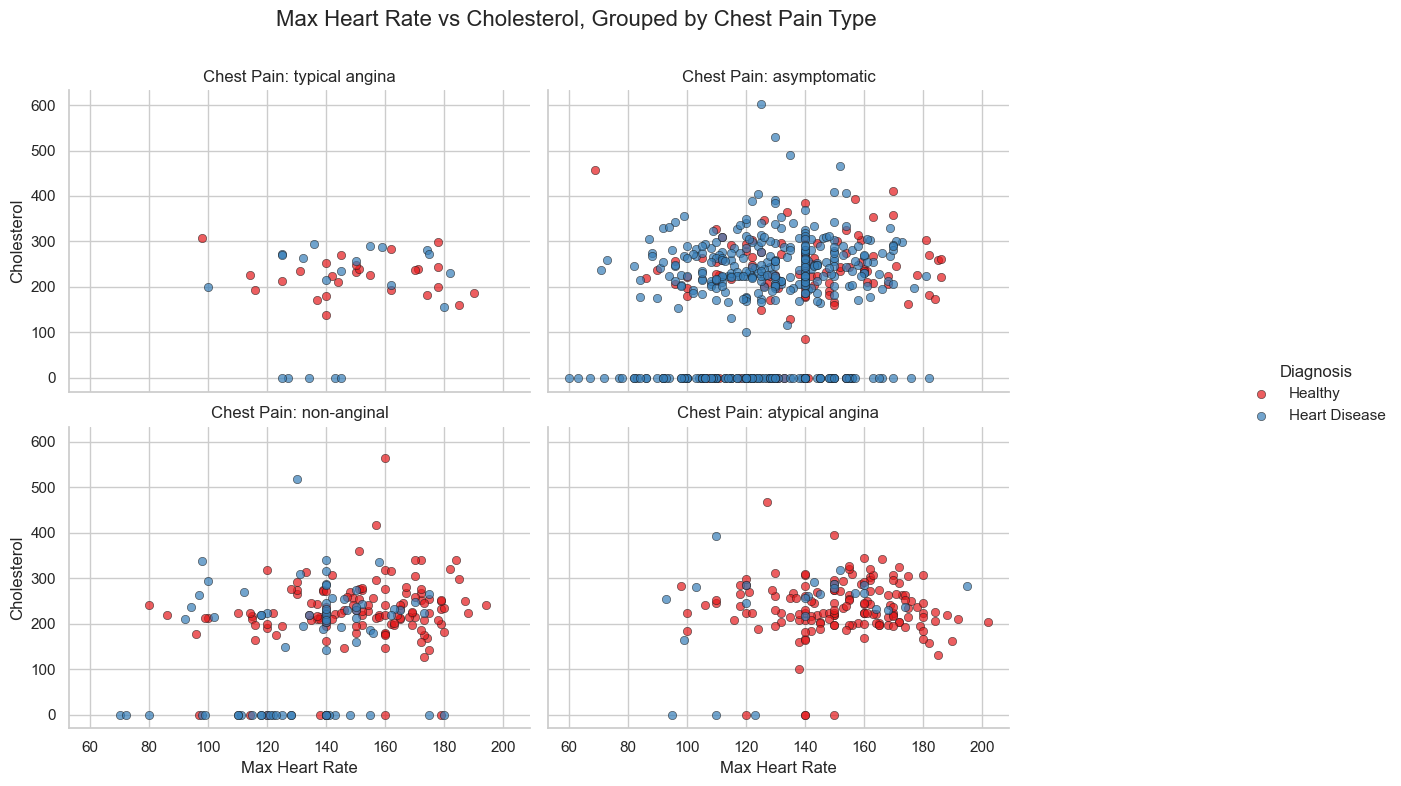

In [24]:
g = sns.FacetGrid(df, col='cp', hue='disease_label', col_wrap=2, height=4, aspect=1.3, palette='Set1')

# Map a scatterplot to the grid
g.map(sns.scatterplot, 'thalch', 'chol', alpha=0.7, edgecolor='k')

# Formatting the grid
g.add_legend(title='Diagnosis', bbox_to_anchor=(1.05, 0.5), loc='center left')
g.set_axis_labels("Max Heart Rate", "Cholesterol")
g.set_titles(col_template="Chest Pain: {col_name}")

# Add main title
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('Max Heart Rate vs Cholesterol, Grouped by Chest Pain Type', fontsize=16)

plt.show()

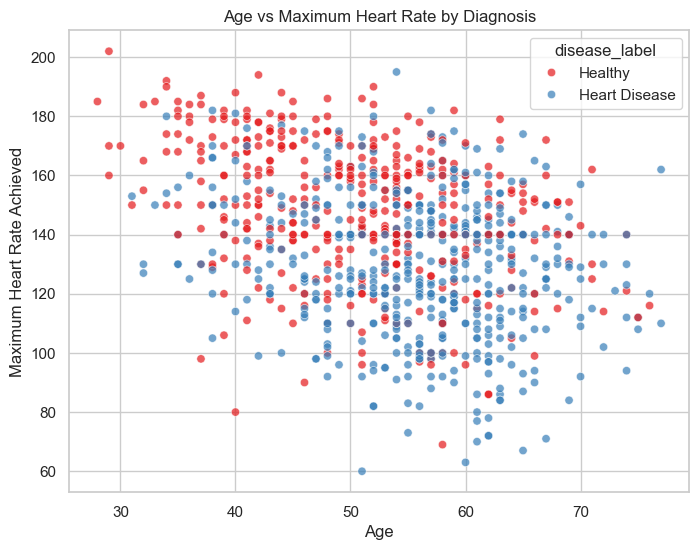

In [14]:
# Add this to dive deeper into specific numeric relationships
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='thalch', hue='disease_label', alpha=0.7, palette='Set1')
plt.title('Age vs Maximum Heart Rate by Diagnosis')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate Achieved')
plt.show()

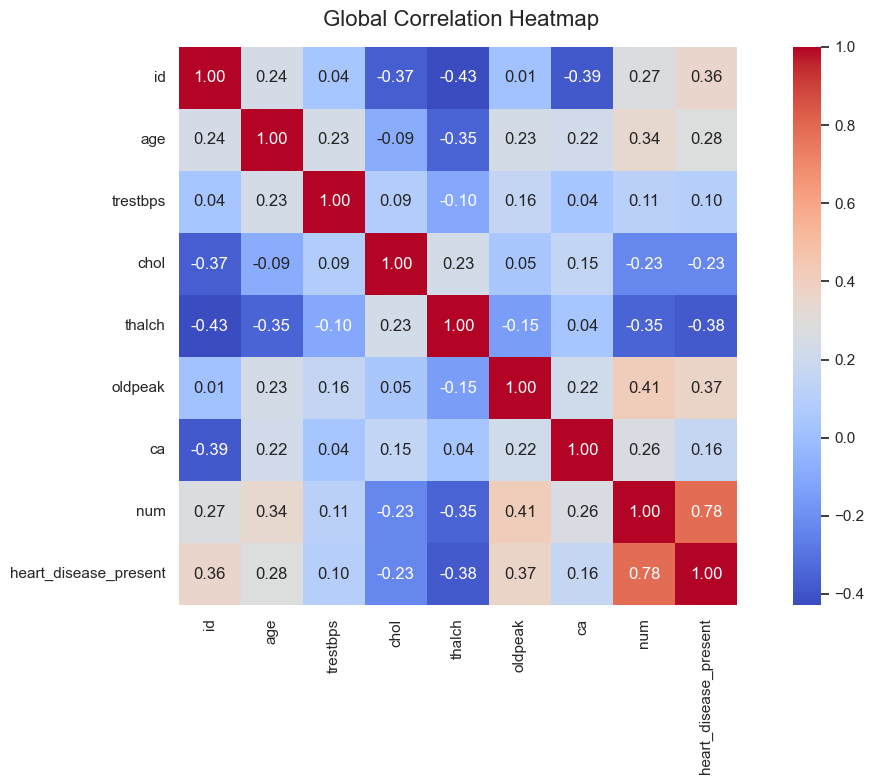

In [16]:
plt.figure(figsize=(12, 8))
# Select only numeric data for correlation math
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title(' Global Correlation Heatmap', fontsize=16, pad=15)
plt.tight_layout()
plt.show()